In [1]:
#Avaliação de Algortimos de Hash para Imagens
#Import das Bibliotecas
#https://pypi.org/project/ImageHash/

import os
import cv2
import hashlib
import imagehash
import matplotlib as mpl

from PIL import Image
from scipy.spatial import *
from matplotlib import pyplot as plot

<b> <a href="https://www.analyticsvidhya.com/blog/2020/02/4-types-of-distance-metrics-in-machine-learning/#:~:text=Hamming%20Distance%20measures%20the%20similarity,the%20corresponding%20characters%20are%20different.&text=Since%20the%20length%20of%20these,can%20calculate%20the%20Hamming%20Distance"> Possíveis Medidas de Avaliação </a> </b>
- Distancia de Hamming
- Distancia Euclidiana / Manhattan / Minkowski?
- Histogramas com Hashes e as Imagens?

<b> Sobre a Distância de Hamming </b>

A distância de Hamming entre duas strings de mesmo comprimento é o número de posições nas quais elas diferem entre si. 
Ou seja, a distância de Hamming é o menor número de substituições necessárias para transformar uma string na outra

<img src="Distances/hammingDistance.jpeg" width="800" height="600">

In [2]:
#Path Definition
path = 'D:/Google Drive/Github/HashFunctions/LennaDatabase/'

In [3]:
#Definição da Imagem Alterada
image_name = str(input("Nome do Arquivo de Imagem Alterada: ") + "." + input("Extensão da Imagem Alterada: "))

Nome do Arquivo de Imagem Alterada: muita-alteracao
Extensão da Imagem Alterada: jpg


In [4]:
#Import da Imagem Original e da Imagem Alterada
original = cv2.imread(path + 'original.jpg')
alterada = cv2.imread(path + image_name)

In [5]:
#Ordenando as Bandas RGB
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)

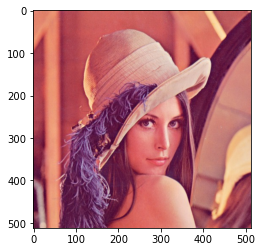

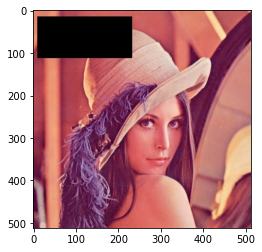

In [6]:
#Exibição das Imagens Carregadas:
plot.imshow(original,cmap='gray')
plot.show()
plot.imshow(alterada,cmap='gray')

In [7]:
#Validação da Imagem com Cópia Renomeada para lenna2
#Export para Cálculos de Hash Perceptivo

alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)
cv2.imwrite(path + 'lenna2.jpg', alterada);

<b> Cálculo de Hash Convencional: MD5, SHA1 e SHA256 </b>

In [8]:
#Import do arquivo binário das Imagens
file1 = path + 'original.jpg'
file2 = path + image_name

In [9]:
#Leitura dos Arquivos
with open(file1, 'rb') as f1:
    data1 = f1.read()
with open(file2, 'rb') as f2:
    data2 = f2.read()

In [10]:
#Cálculo do valor Hash Md5, Sha1 e Sha256 dos Arquivos Binários
md5_original = str(hashlib.md5(data1).hexdigest())
md5_alterada = str(hashlib.md5(data2).hexdigest())

sha1_original = str(hashlib.sha1(data1).hexdigest())
sha1_alterada = str(hashlib.sha1(data2).hexdigest())

sha256_original = str(hashlib.sha256(data1).hexdigest())
sha256_alterada = str(hashlib.sha256(data2).hexdigest())

<b> Cálculo de Hash Perceptual </b>

Os principais Tipos de Hash Perceptivos são:
- Average hashing
- Perceptual hashing
- Difference hashing
- Wavelet hashing
- HSV color hashing (colorhash)
- Crop-resistant hashing

In [11]:
#Criação da Função de Cálculo da Distância de Hamming
def hamming(hash1,hash2):
    L = len(hash1)
    distance = 0
    
    for i in range(L):
        if hash1[i] != hash2[i]:
            distance += 1

    return(str(distance))

In [12]:
#Average Hashing
ahash1 = str(imagehash.average_hash(Image.open('LennaDatabase/original.jpg')))
ahash2 = str(imagehash.average_hash(Image.open('LennaDatabase/lenna2.jpg')))
ahash_dist = hamming(ahash1,ahash2)

In [13]:
#Perceptual Hashing
phash1 = str(imagehash.phash(Image.open('LennaDatabase/original.jpg')))
phash2 = str(imagehash.phash(Image.open('LennaDatabase/lenna2.jpg')))
phash_dist = hamming(phash1,phash2)

In [14]:
#Difference Hashing
dhash1 = str(imagehash.dhash(Image.open('LennaDatabase/original.jpg')))
dhash2 = str(imagehash.dhash(Image.open('LennaDatabase/lenna2.jpg')))
dhash_dist = hamming(dhash1,dhash2)

In [15]:
#Wavelet Hashing
whash1 = str(imagehash.whash(Image.open('LennaDatabase/original.jpg')))
whash2 = str(imagehash.whash(Image.open('LennaDatabase/lenna2.jpg')))
whash_dist = hamming(whash1,whash2)

In [16]:
#HSV Color Hashing
hsvhash1 = str(imagehash.colorhash(Image.open('LennaDatabase/original.jpg')))
hsvhash2 = str(imagehash.colorhash(Image.open('LennaDatabase/lenna2.jpg')))
hsvhash_dist = hamming(hsvhash1,hsvhash2)

<b> Cálculo de Hash Perceptual - Crop Resistance Hashing </b>

In [17]:
#Crop-Resistant Hashing
crhash1 = imagehash.crop_resistant_hash(Image.open('LennaDatabase/original.jpg'))
crhash2 = imagehash.crop_resistant_hash(Image.open('LennaDatabase/lenna2.jpg'))

ArrayImage01 = str(crhash1).split(',')
ArrayImage02 = str(crhash2).split(',')

if len(ArrayImage01) <= len(ArrayImage02):
    menor = len(ArrayImage01)
    maior = len(ArrayImage02)
    
    total = maior - menor
    for i in range(total):
        ArrayImage01.append('################')
    
elif len(ArrayImage02) < len(ArrayImage01):
    menor = len(ArrayImage02)
    maior = len(ArrayImage01)
    
    total = maior - menor
    for i in range(total):
        ArrayImage02.append('################')

# Resultados

<b> Exibição dos Resultados do Hash Convencional </b>

In [18]:
#Resultados Finais (Arquivos de Hash)
print("\nMD5 Original: " + md5_original)
print("MD5 Alterado: " + md5_alterada)

print("\nSha1 Original: " + sha1_original)
print("Sha1 Alterado: " + sha1_alterada)

print("\nSha256 Original: " + sha256_original)
print("Sha256 Alterado: " + sha256_alterada)


MD5 Original: 0eaf36d4881c513ca70b6684bfaa5b08
MD5 Alterado: 410e10ab15dc9083b37419b72fbc77d9

Sha1 Original: 9a6d6e48b2e5d31eb9e2f38adb877140fa4b1538
Sha1 Alterado: 6530ba8542e24619c5d53dbbc596803825c5551b

Sha256 Original: ebe926ee8951fd5e1282b0945f72c00125c33819a4584dcceb258dbe1c6a1149
Sha256 Alterado: 71f5c71472a0186d41c1ad4528f34d5aab68c9b7ccc65e7ed3d62296357aaade


<b> Exibição dos Resultados do Hash Perceptual </b>

In [19]:
def show_perceptual(hash_type,hash1,hash2,distance):
    print("\n" + str(hash_type) + " da Imagem Original: " + str(hash1))
    print(str(hash_type) + " da Imagem Alterada: " + str(hash2))
    print("A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: " + str(distance))    

In [20]:
#Resultados Finais (Hash Perceptual)
show_perceptual("Average Hashing",ahash1,ahash2,ahash_dist)
show_perceptual("Perceptual Hashing",phash1,phash2,phash_dist)
show_perceptual("Difference Hashing",dhash1,dhash2,dhash_dist)
show_perceptual("Wavelet Hashing",whash1,whash2,whash_dist)
show_perceptual("HSV Color Hashing",hsvhash1,hsvhash2,hsvhash_dist)


Average Hashing da Imagem Original: b69cbd890b0b8f8c
Average Hashing da Imagem Alterada: 0e0efdcd9b8b8f8e
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 10

Perceptual Hashing da Imagem Original: 99c6562d7533a296
Perceptual Hashing da Imagem Alterada: 9914142d75e3e6d6
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 8

Difference Hashing da Imagem Original: 7670795b33135a38
Difference Hashing da Imagem Alterada: 7e30795b33135a38
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 2

Wavelet Hashing da Imagem Original: be98bd890b0b8f8c
Wavelet Hashing da Imagem Alterada: 0e0ebd8d8b0b8f8e
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 6

HSV Color Hashing da Imagem Original: 006000c0001
HSV Color Hashing da Imagem Alterada: 006000c0001
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 0


<b> Exibição dos Resultados do Hash Perceptual - Crop Resistance Hashing </b>

In [21]:
##Resultados Finais (Hash Perceptual - Crop-Resistant Hash)
total = 0
for i in range(maior):
    print("Crop-Resistant Hashing da Imagem Original: " + str(i + 1) + "ª Redução: " + str(ArrayImage01[i]))
    print("Crop-Resistant Hashing da Imagem Alterada: " + str(i + 1) + "ª Redução: " + str(ArrayImage02[i]))
    
    distance = 0
    string1 = ArrayImage01[i]
    string2 = ArrayImage02[i]
    
    for n in range(len(string1)):        
        if string1[n] != string2[n]:
            distance += 1
    
    total = total + distance
    print("A Distância de Hamming do Crop-Resistant Hashing é: " + str(distance))
    print("\n")

print("O total das 8 Distancias de Hamming do Crop-Resistance é: " + str(total))
print("Dividido por 8: " + str(total/8))

Crop-Resistant Hashing da Imagem Original: 1ª Redução: 1838bc3c3c3cd8cc
Crop-Resistant Hashing da Imagem Alterada: 1ª Redução: c4c0cc6c2cac2c2c
A Distância de Hamming do Crop-Resistant Hashing é: 11


Crop-Resistant Hashing da Imagem Original: 2ª Redução: cce5f172e767767a
Crop-Resistant Hashing da Imagem Alterada: 2ª Redução: dccdb366e76f66f2
A Distância de Hamming do Crop-Resistant Hashing é: 11


Crop-Resistant Hashing da Imagem Original: 3ª Redução: 67c6808082e23019
Crop-Resistant Hashing da Imagem Alterada: 3ª Redução: bc3c3c3c3c3cd8cc
A Distância de Hamming do Crop-Resistant Hashing é: 16


Crop-Resistant Hashing da Imagem Original: 4ª Redução: eede5bc79e67676f
Crop-Resistant Hashing da Imagem Alterada: 4ª Redução: c7c6808082e03099
A Distância de Hamming do Crop-Resistant Hashing é: 16


Crop-Resistant Hashing da Imagem Original: 5ª Redução: 016558c4f1f9f4fe
Crop-Resistant Hashing da Imagem Alterada: 5ª Redução: 362eaba78da6b7bf
A Distância de Hamming do Crop-Resistant Hashing é: 